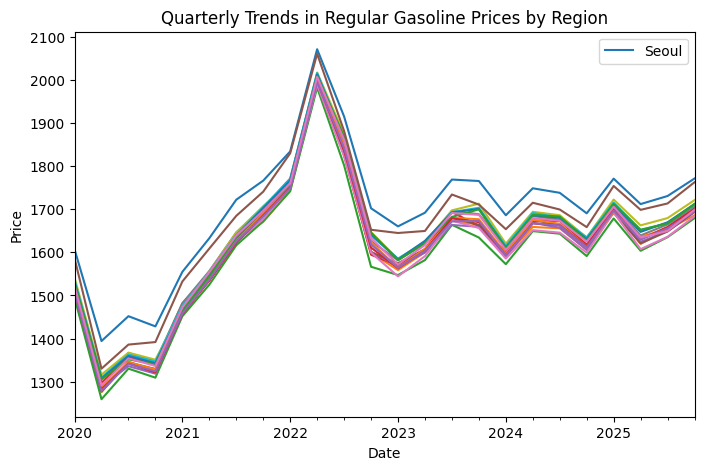

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

oil = pd.read_csv('/content/sample_data/project/주유소_지역별_평균판매가격 (보통휘발유).csv', encoding = 'cp949')

# 2025년 1분기 -> 2025-01-01로 바꾸기
oil['날짜'] = oil['구분'].str.replace('년', '-').str.replace('1분기', '01-01')
oil['날짜'] = oil['날짜'].str.replace('2분기', '04-01')
oil['날짜'] = oil['날짜'].str.replace('3분기', '07-01')
oil['날짜'] = oil['날짜'].str.replace('4분기', '10-01')

# 문자열 데이터 (시리즈 객체)를 판다스 Timestamp로 변환
oil['날짜'] = pd.to_datetime(oil['날짜'])

# 시계열 값으로 변환된 열을 새로운 행 인덱스로 지정, 기존 날짜 열은 삭제
oil = oil.set_index('날짜')
oil = oil.drop('구분', axis = 1)

# 서울 분기 별 가격 변화 그래프
oil.plot(figsize = (8, 5));
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Quarterly Trends in Regular Gasoline Prices by Region')
plt.legend(['Seoul', 'Busan', 'Daegu', 'Incheon', 'Gwangju', 'Daejeon'])

In [ ]:
import matplotlib.pyplot as plt

# 서울과 부산 데이터 시각화
plt.figure(figsize=(10, 5))
plt.plot(oil['날짜'], oil['서울'], label='서울 유가') # Legend를 위한 label 설정
plt.plot(oil['날짜'], oil['부산'], label='부산 유가') # Legend를 위한 label 설정

plt.xlabel('연도 및 분기') # X축 Label
plt.ylabel('가격 (원)')    # Y축 Label
plt.title('지역별 유가 추이 비교')

plt.legend() # 설정한 label들을 모아서 범례로 표시
plt.xticks(rotation=45) # X축 글자 겹침 방지
plt.show()

KeyError: '날짜'

<Figure size 1000x500 with 0 Axes>